/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning:

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

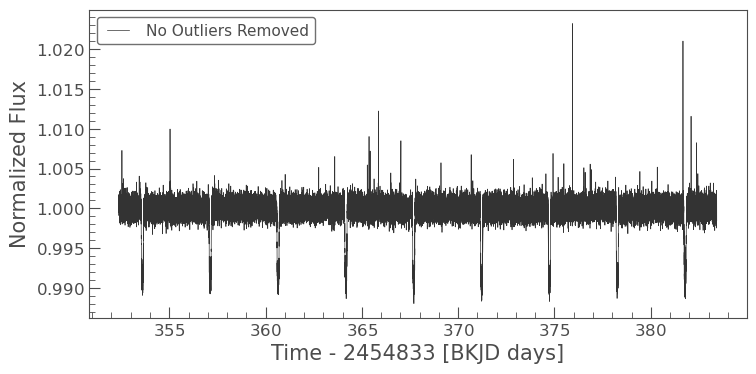

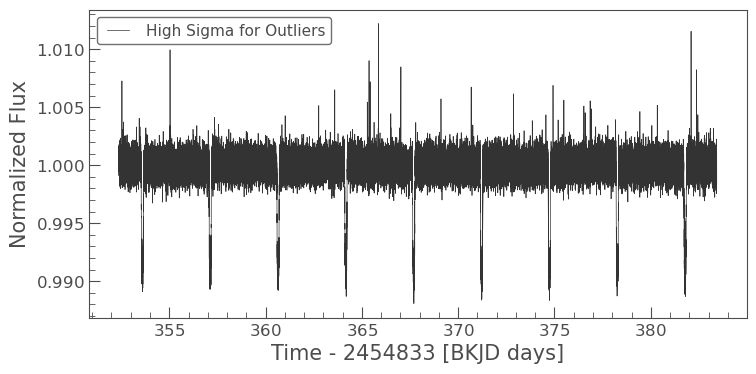

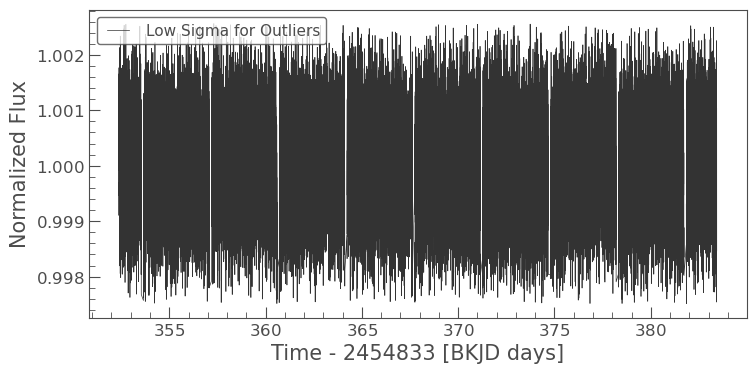

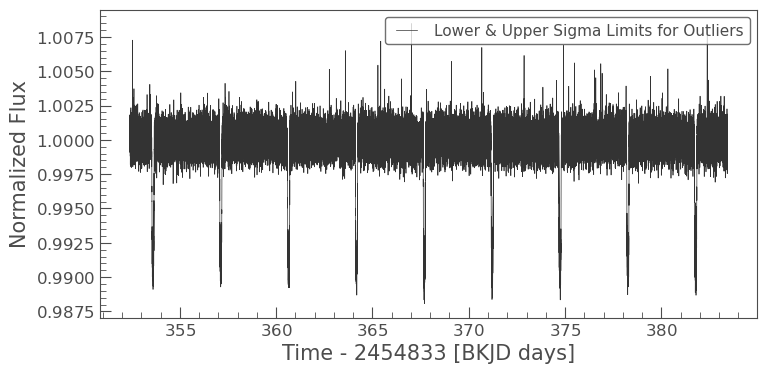

In [60]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve

# Download Kepler light curve & clean it up
lc_nooutliers = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize()
lc_highsigma = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=9)
lc_lowsigma = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=3)
lc_sigmalowerandupper = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma_lower=100, sigma_upper=5)


lc_nooutliers.plot(label="No Outliers Removed")
lc_highsigma.plot(label="High Sigma for Outliers")
lc_lowsigma.plot(label="Low Sigma for Outliers")
lc_sigmalowerandupper.plot(label="Lower & Upper Sigma Limits for Outliers")









/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
The requested periodogram is not evenly sampled in frequency.
Method has been changed from 'fast' to 'slow' to allow for this.


Lomb-Scargle period: 1.7600 d days
BLS period: 3.5200 d days


<Axes: title={'center': 'BLS Periodogram'}, xlabel='Period (days)', ylabel='Power'>

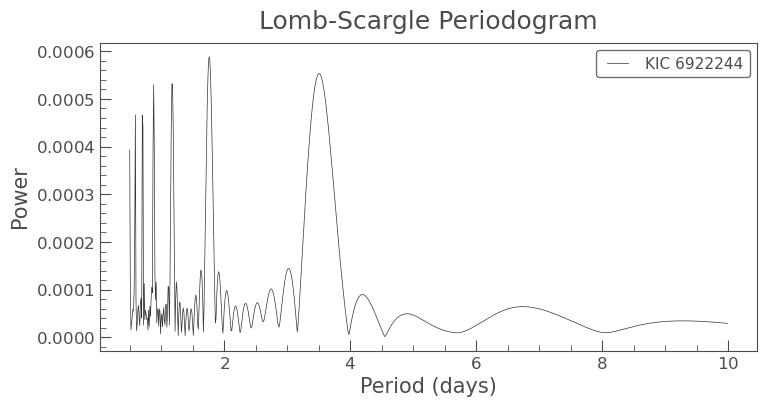

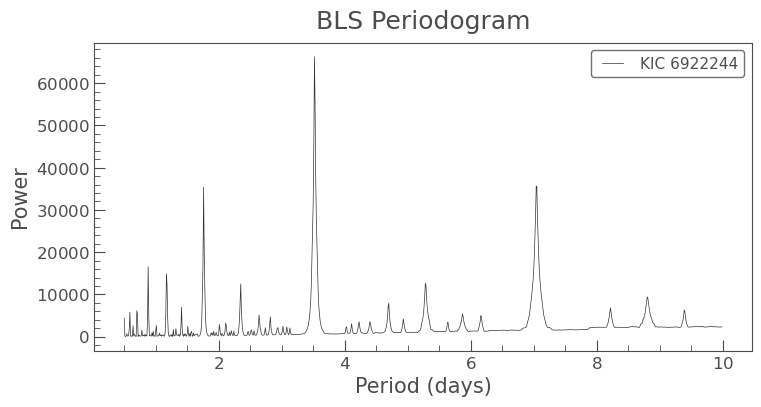

In [61]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve

lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=9)

pd_lombscargle = lc.to_periodogram(method="Lombscargle", period=np.arange(0.5, 10, 0.01))
pd_bls = lc.to_periodogram(method="bls", period=np.arange(0.5, 10, 0.01))

period_lombscargle = pd_lombscargle.period_at_max_power
period_bls = pd_bls.period_at_max_power

print(f"Lomb-Scargle period: {period_lombscargle:.4f} days")
print(f"BLS period: {period_bls:.4f} days")

pd_lombscargle.plot(title="Lomb-Scargle Periodogram", xlabel="Period (days)", ylabel="Power")
pd_bls.plot(title="BLS Periodogram", xlabel="Period (days)", ylabel="Power")


/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


window = 101: F_in = 0.99995, F_out = 0.99997, depth = 0.002%
window = 201: F_in = 0.99998, F_out = 0.99997, depth = -0.001%
window = 401: F_in = 0.99999, F_out = 0.99997, depth = -0.002%
window = 801: F_in = 0.99999, F_out = 0.99997, depth = -0.002%


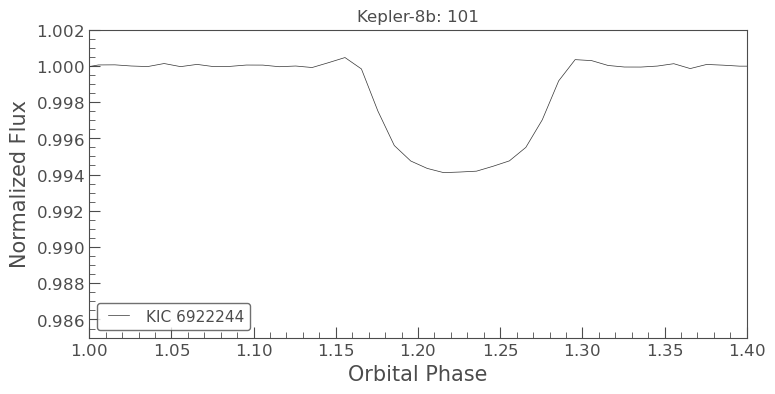

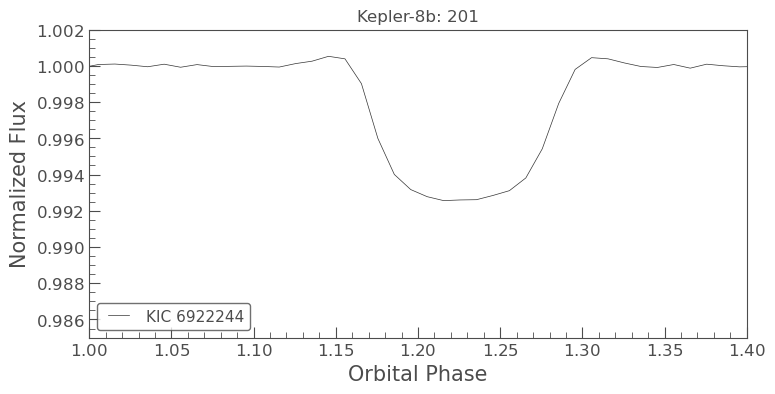

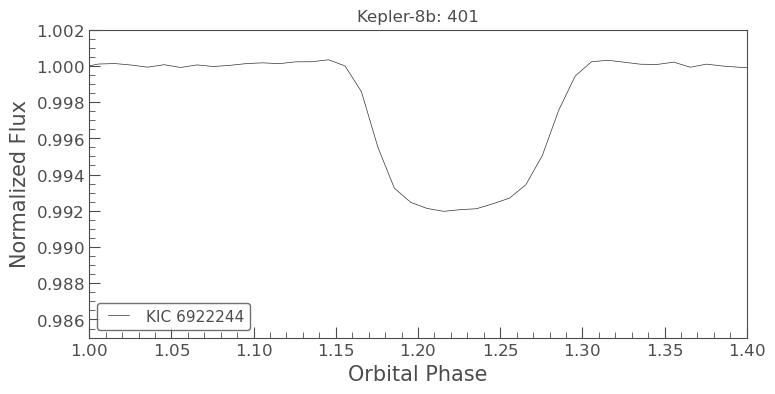

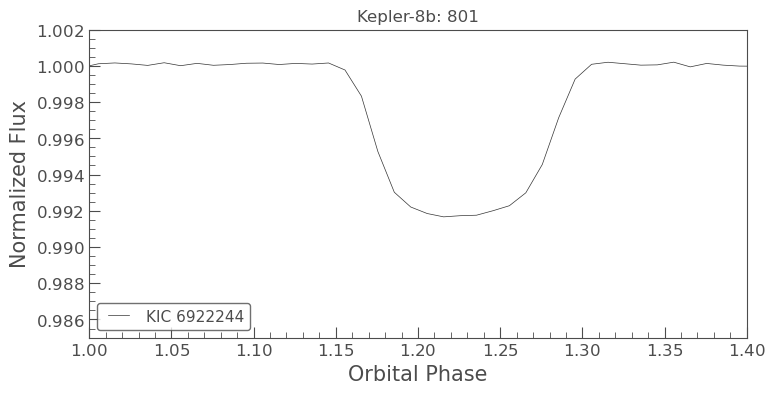

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve

lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=9)

# ---Not flattened + Not Binned LC

pd_bls = lc.to_periodogram(method="bls", period=np.arange(0.5, 10, 0.01))
period_bls = pd_bls.period_at_max_power
t0_bls = pd_bls.transit_time_at_max_power

lc_uncleanfold = lc.fold(period=period_bls, )

'''ax_unclean = lc_uncleanfold.plot()

ax_unclean.set_xlabel("Orbital Phase")
ax_unclean.set_ylabel("Normalized Flux")
ax_unclean.set_title("Kepler-8b: No Flattening or Binning") '''



# --- Flattened + Binned LC


lc_flattend = lc.flatten(window_length=401)
    
lc_folded = lc_flattend.fold(period=period_bls)

lc_clean = lc_folded.bin(time_bin_size=0.01)

'''ax_clean = lc_clean.plot()

ax_clean.set_xlabel("Orbital Phase")
ax_clean.set_ylabel("Normalized Flux")
ax_clean.set_title("Kepler-8b: window_length = 401") '''

window_lengths = [101, 201, 401, 801]

for window in window_lengths:
    
    lc_flat = lc.flatten(window_length=window)
    lc_folded = lc_flat.fold(period=period_bls, )
    lc_binned = lc_folded.bin(time_bin_size=0.01)
    lc_binned.plot()
    
    
    plt.xlabel("Orbital Phase")
    plt.ylabel("Normalized Flux")
    plt.title(f"Kepler-8b: {window}")
    
    plt.xlim(1.0, 1.4)
    plt.ylim(0.985, 1.002)
    
    phase = lc_folded.phase.value
    flux = lc_folded.flux.value

    in_transit = np.abs(phase) < 0.02
    out_transit = np.abs(phase) > 0.05

    F_in = np.median(flux[in_transit])
    F_out = np.median(flux[out_transit])

    depth = (F_out - F_in) / F_out

    print(
        f"window = {window}: "
        f"F_in = {F_in:.5f}, "
        f"F_out = {F_out:.5f}, "
        f"depth = {depth*100:.3f}%"
    )
    
    

    
    
